# 3. K-means klustring & tolkning

**Frågeställning:** Vilka kundtyper finns i vår kundbas och hur når vi dem bäst?

**Gruppmedlemmar:** David Fjellström, Anton  
**Input:** Data/clean_customer_data.csv

---
## 3.1 Ladda in rent dataset

Läs in `clean_customer_data.csv` från datareningen.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

df = pd.read_csv('Data/clean_customer_data.csv')
df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age
0,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,...,4,7,0,0,0,0,0,0,1,69
1,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,...,2,5,0,0,0,0,0,0,0,72
2,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,...,10,4,0,0,0,0,0,0,0,61
3,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,...,4,6,0,0,0,0,0,0,0,42
4,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,...,6,5,0,0,0,0,0,0,0,45


In [2]:
# TotalSpend och HasChildren skapades i EDA men sparades inte i CSV:en
spend_cols = ['MntWines', 'MntFruits', 'MntMeatProducts',
              'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df['TotalSpend'] = df[spend_cols].sum(axis=1)
df['HasChildren'] = ((df['Kidhome'] + df['Teenhome']) > 0).astype(int)

---
## 3.2 Välj och förbered variabler

- Vilka variabler använder vi för klustring och varför?
- Skalning — varför behöver vi normalisera innan k-means?
- Hantera eventuella kategoriska variabler

In [3]:
# Variabler valda utifrån EDA:ns tre starkaste differentiatorer:
# inkomst/köpkraft, barn-status, och de dominerande produktkategorierna
features = ['Income', 'TotalSpend', 'HasChildren', 'MntWines', 'MntMeatProducts']
X = df[features].copy()

# Utan skalning dominerar Income (50 000-tal) helt över HasChildren (0 eller 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

---
## 3.3 Välj antal kluster

- Elbow-metoden — plotta inertia mot antal kluster
- Silhouette score som komplement
- Vilket antal kluster väljer vi och varför?

In [4]:
# inertia: hur väl klustren passar data (lägre = bättre)
# silhouette: hur väl separerade klustren är (högre = bättre)
# båda metoderna används för att hitta det optimala antalet kluster (k) i KMeans
inertia = []
silhouette_scores = []
k_range = range(2, 9)

# Loopa över olika k-värden, träna KMeans och beräkna både inertia och silhouette score
for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, model.labels_))

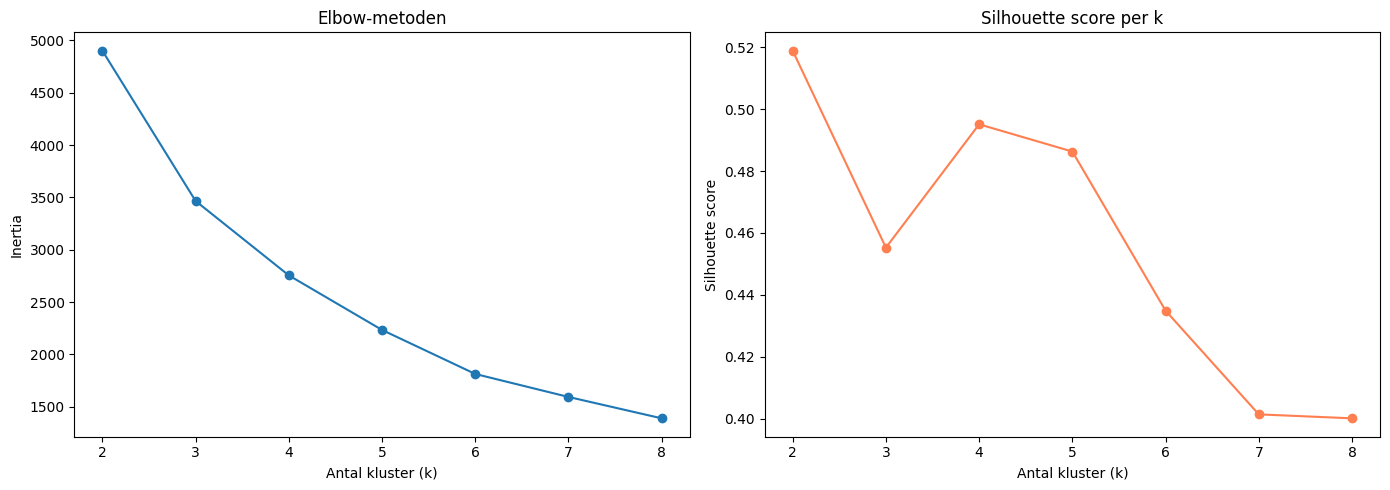

In [5]:
# Visualisera både Elbow-metoden och Silhouette scores för att hitta det optimala k
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow: böjen i kurvan markerar ett lämpligt antal kluster
axes[0].plot(k_range, inertia, marker='o')
axes[0].set_title('Elbow-metoden')
axes[0].set_xlabel('Antal kluster (k)')
axes[0].set_ylabel('Inertia')

# Silhouette: mäter hur väl separerade klustren är (högre = bättre)
axes[1].plot(k_range, silhouette_scores, marker='o', color='coral')
axes[1].set_title('Silhouette score per k')
axes[1].set_xlabel('Antal kluster (k)')
axes[1].set_ylabel('Silhouette score')

# Justera layout och visa plotten
plt.tight_layout()
plt.show()

---
## 3.4 Träna modellen

- Kör k-means med valt antal kluster
- Tilldela varje kund ett klusternummer
- Hur många kunder hamnade i respektive kluster?

In [6]:
# Kör k-means med valt antal kluster
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

# Tilldelar varje kund ett klusternummer (0 till 3)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Hur många kunder hamnade i respektive kluster?
print(df['Cluster'].value_counts().sort_index())

Cluster
0    1082
1     456
2     489
3     178
Name: count, dtype: int64


---
## 3.5 Visualisera klustren

- PCA för att reducera till 2 dimensioner och plotta klustren
- Boxplots per kluster för nyckelvariabler (inkomst, utgifter, ålder)
- Vad syns tydligt visuellt?

### PCA

Förklarad varians: 88.0%


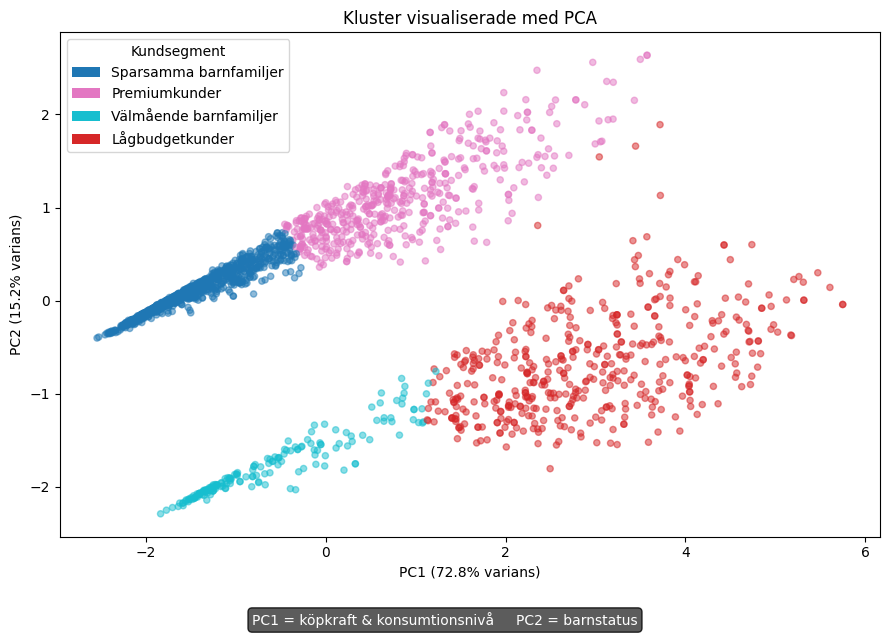

In [17]:
# PCA - används för att visualisera klustren i ett 2D-plan
# Vi har 5 variabler (dimensioner) — PCA krymper dem till 2 så vi kan rita en graf
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Hur mycket av informationen behålls efter krympningen?
print(f'Förklarad varians: {pca.explained_variance_ratio_.sum():.1%}')



# Rita klustren i det nya 2D-planet
plt.figure(figsize=(9, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=df['Cluster'], cmap='tab10', alpha=0.5, s=20)
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor='tab:blue', label='Sparsamma barnfamiljer'),
    Patch(facecolor='tab:pink', label='Premiumkunder'),
    Patch(facecolor='tab:cyan', label='Välmående barnfamiljer'),
    Patch(facecolor='tab:red', label='Lågbudgetkunder')
]

plt.legend(handles=legend_elements, title='Kundsegment')

plt.title('Kluster visualiserade med PCA')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varians)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varians)')
plt.tight_layout()
plt.figtext(0.5, -0.05,
            'PC1 = köpkraft & konsumtionsnivå     PC2 = barnstatus',
            ha='center', fontsize=10, color='white',
            bbox=dict(boxstyle='round', facecolor='#333333', alpha=0.8))
plt.show()

### Boxplots

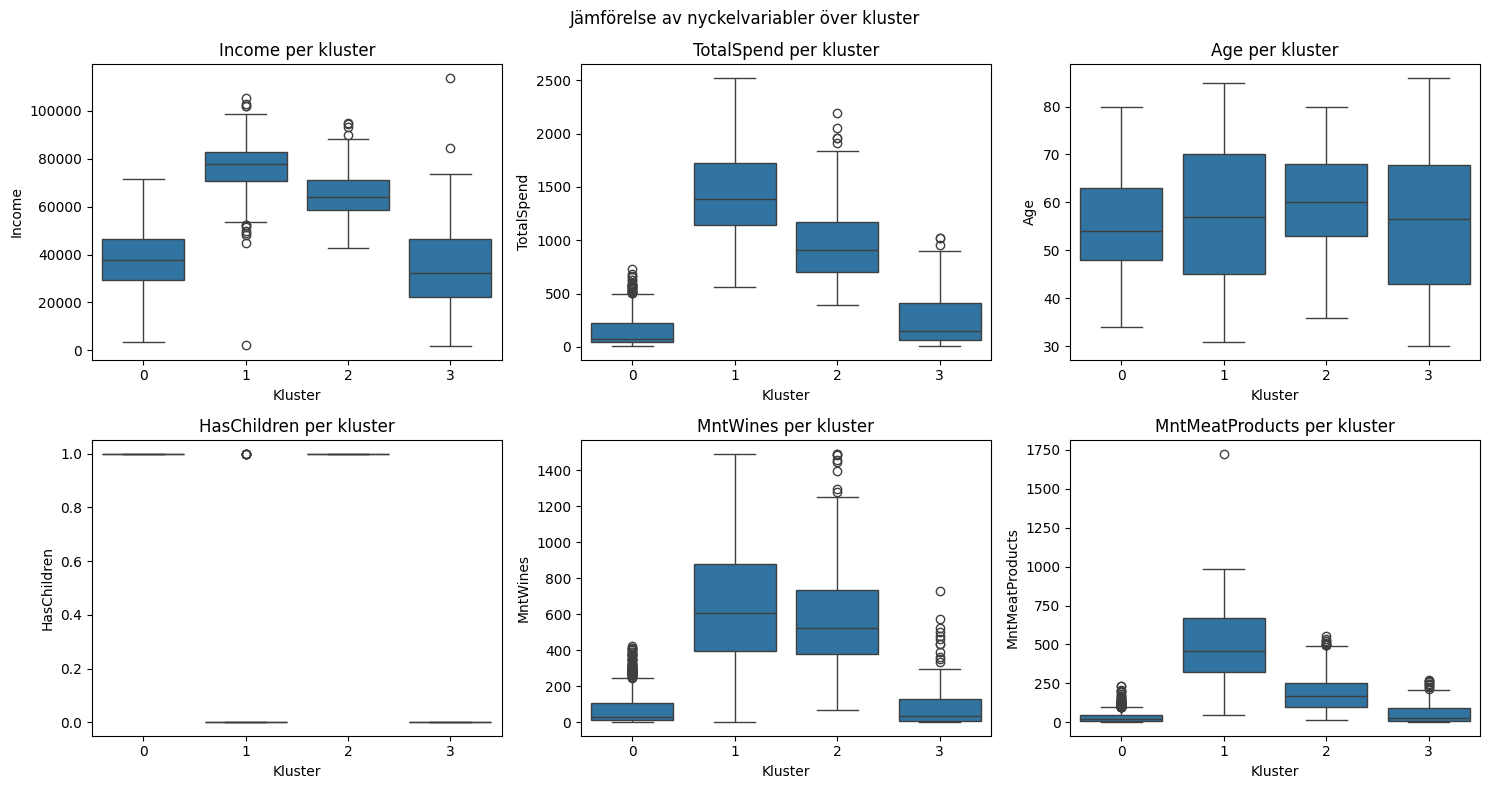

In [8]:
# Visar hur de 4 klustren skiljer sig åt för varje nyckelvariabel
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
key_vars = ['Income', 'TotalSpend', 'Age', 'HasChildren', 'MntWines', 'MntMeatProducts']

for i, var in enumerate(key_vars):
    row, col = divmod(i, 3)
    sns.boxplot(x='Cluster', y=var, data=df, ax=axes[row, col])
    axes[row, col].set_title(f'{var} per kluster')
    axes[row, col].set_xlabel('Kluster')
    axes[row, col].set_ylabel(var)

plt.suptitle('Jämförelse av nyckelvariabler över kluster')
plt.tight_layout()
plt.show()

---
## 3.6 Karaktärisera klustren

- Vad är medelvärdet för nyckelvariabler per kluster?
- Ge varje kluster ett beskrivande namn (t.ex. "Högutgiftare", "Barnfamiljer")
- Jämför klustren mot varandra

### Medelvärden per kluster

In [9]:
# Beräknar medelvärdet för varje nyckelvariabler per kluster
# Används som underlag för att namnge och tolka segmenten
profile_cols = ['Income', 'TotalSpend', 'HasChildren', 'Age', 'MntWines', 'MntMeatProducts']
cluster_profile = df.groupby('Cluster')[profile_cols].mean().round(1)
cluster_profile

,Income,TotalSpend,HasChildren,Age,MntWines,MntMeatProducts
Cluster,,,,,,
0,37695.8,147.5,1.0,55.4,73.1,32.6
1,76859.3,1443.5,0.0,57.8,648.9,493.3
2,64956.2,967.8,1.0,60.6,579.8,190.9
3,34991.1,264.0,0.0,56.2,93.4,61.5


### Klusternamn

| Kluster | Namn | Beskrivning |
|---|---|---|
| 0 | Sparsamma barnfamiljer | Låg inkomst, har barn, minimal utgift |
| 1 | Premiumkunder | Hög inkomst, inga barn, hög utgift på vin och kött |
| 2 | Välmående barnfamiljer | Medelhög inkomst, har barn, relativt hög utgift |
| 3 | Lågbudgetkunder | Låg inkomst, inga barn, låg utgift |

### Heatmap för jämförelse

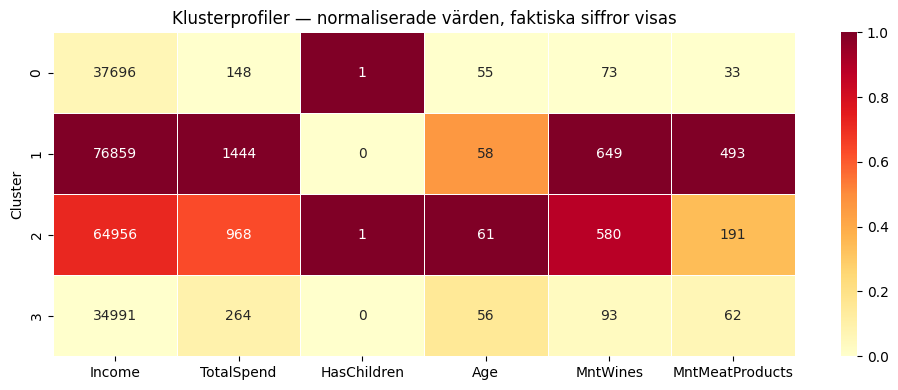

In [10]:
# Heatmap ger en snabb visuell överblick över hur klustren skiljer sig åt
# normalize=True skalar varje kolumn så att de går att jämföra trots olika enheter
cluster_norm = cluster_profile.apply(lambda x: (x - x.min()) / (x.max() - x.min()))

plt.figure(figsize=(10, 4))
sns.heatmap(cluster_norm, annot=cluster_profile, fmt='.0f',
            cmap='YlOrRd', linewidths=0.5)
plt.title('Klusterprofiler — normaliserade värden, faktiska siffror visas')
plt.tight_layout()
plt.show()


---
## 3.7 Marknadsföringsrekommendationer per segment

- Vad betyder varje kundsegment för ett företag?
- Vilka marknadsföringsstrategier passar respektive segment?
- Vilka segment är mest värdefulla och varför?

### Kluster 1 — Premiumkunder (456 kunder)
- Högst inkomst (77k), störst utgift (1 444 kr), inga barn. Dominerar i vin och kött.

- Affärsvärde: Mest lönsamma kunder per person.

- Stretegi: Premiumkampanjer, lojalitetsprogram, exklusiva erbjudanden på vin och delikatesser. Hög sannolikhet att acceptera kampanjer.

### Kluster 2 — Välmående barnfamiljer (489 kunder)
- Medelhög inkomst (65k), har barn, relativt hög utgift (968 kr).

- Affärsvärde: Näst mest lönsamma segmentet — stor grupp med god köpkraft.

- Strategi: Familjeerbjudanden, bundlade produkter, kampanjer kring högtider och säsong.

### Kluster 0 — Sparsamma barnfamiljer (1 082 kunder)
- Störst grupp men låg utgift (148 kr). Har barn och lägre inkomst (38k).

- Affärsvärde: Stor volym men lågt värde per kund — potential att växa med rätt erbjudanden.

- Strategi: Prisrabatter och deals — dessa kunder är priskänsliga.

### Kluster 3 — Lågbudgetkunder (178 kunder)
- Låg inkomst (35k), inga barn, minimal utgift (264 kr).

- Affärsvärde: Lägst prioritet — svåra att konvertera till storköpare.

- Strategi: Lågprisalternativ och introerbjudanden för att öka engagemang.

---
## 3.8 Slutsats

Analysen identifierade fyra tydliga kundsegment som bekräftar det EDA visade: **inkomst** och **barnstatus** är de starkaste drivkrafterna bakom köpbeteende.

**Kluster 1 — Premiumkunder** är det mest lönsamma segmentet per kund (1 444 kr/kund) trots att de bara utgör 21% av kundbasen. De är också de mest kampanjmottagliga.

**Kluster 2 — Välmående barnfamiljer** är det näst mest lönsamma segmentet och en stor grupp (489 kunder) — hög prioritet för familjeanpassade erbjudanden.

**Kluster 0 — Sparsamma barnfamiljer** är den största gruppen (1 082 kunder, 49% av kundbasen) men spenderar minst. Potentialen är stor om rätt prissatta erbjudanden riktas mot dem.

**Kluster 3 — Lågbudgetkunder** är minst (178 kunder) och har lägst köpkraft — lägst prioritet för dyra kampanjinsatser.

PCA förklarar 88% av variansen med bara 2 komponenter, vilket bekräftar att segmenten är väldefinierade och att variabelvalen var träffsäkra.